In [1]:
import pandas as pd

In [2]:
teams = pd.read_csv("teams.csv")

In [3]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [4]:
teams = teams[["team","country","year","athletes","age","prev_medals","medals"]]

In [5]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("teams.csv")

In [11]:
print(df.dtypes)

team                 str
country              str
year               int64
events             int64
athletes           int64
age              float64
height           float64
weight           float64
medals             int64
prev_medals      float64
prev_3_medals    float64
dtype: object


In [12]:
import pandas as pd

df = pd.read_csv("teams.csv")

# Convert categorical columns into numbers
df = pd.get_dummies(df, columns=["team", "country"], drop_first=True)

print(df.dtypes)

year                      int64
events                    int64
athletes                  int64
age                     float64
height                  float64
                         ...   
country_West Germany       bool
country_Yemen              bool
country_Yugoslavia         bool
country_Zambia             bool
country_Zimbabwe           bool
Length: 461, dtype: object


In [14]:
import seaborn as sns

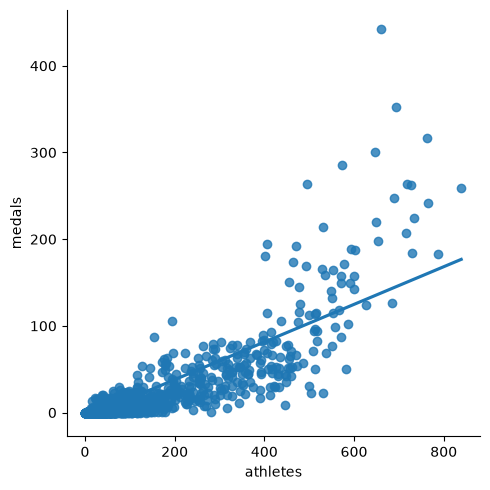

In [15]:
sns.lmplot(x="athletes", y="medals", data=teams, fit_reg=True, ci=None)

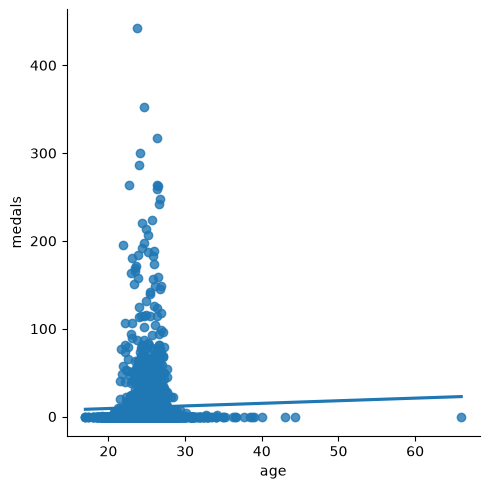

In [16]:
sns.lmplot(x="age", y="medals", data=teams, fit_reg=True, ci=None)

<Axes: ylabel='Frequency'>

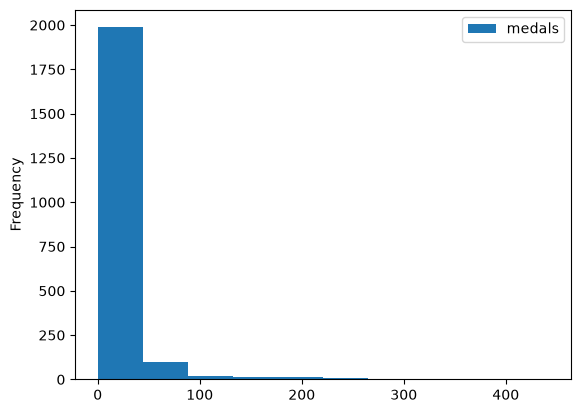

In [17]:
teams.plot.hist(y="medals")

In [18]:
teams[teams.isnull().any(axis=1)]

,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,NaN,0
2103,YAR,North Yemen,1984,3,27.7,NaN,0
2105,YEM,Yemen,1992,8,19.6,NaN,0
2112,YMD,South Yemen,1988,5,23.6,NaN,0


In [19]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [20]:
train.shape

(1736, 7)

In [21]:
test.shape

(408, 7)

In [22]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [25]:
predictors = ["athletes", "prev_medals"]
target = "medals"

In [28]:
reg.fit(train[predictors], train["medals"])
LinearRegression()

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [29]:
teams = teams.dropna()

In [30]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [31]:
predictors = ["athletes", "prev_medals"]
target = "medals"

In [38]:
reg.fit(train[predictors], train["medals"])
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
predictors = ["athletes", "prev_medals"]
target = "medals"

print(train[predictors + [target]].isna().sum())

athletes         0
prev_medals    127
medals           0
dtype: int64


In [34]:
train = train.dropna(subset=predictors + [target])

In [35]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

predictors = ["athletes", "prev_medals"]
target = "medals"

train = train.dropna(subset=predictors + [target])

reg.fit(train[predictors], train[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.07,0.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['athletes','prev_medals']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.142
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [36]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [37]:
predictors = ["athletes", "prev_medals"]
target = "medals"

In [39]:
reg.fit(train[predictors], train["medals"])
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
predictions = reg.fit(test[predictors])

TypeError: LinearRegression.fit() missing 1 required positional argument: 'y'

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
predictors = ["athletes", "prev_medals"]

# Remove rows with missing predictor values
test = test.dropna(subset=predictors)

# Make predictions
predictions = reg.predict(test[predictors])

print(predictions)

[-9.61221245e-01 -1.17633261e+00 -1.42503158e+00 -1.71184673e+00
  2.15562926e+00  3.91463636e+00 -1.71184673e+00 -1.85525431e+00
  3.67563128e-01 -2.77770967e-01 -1.85525431e+00 -1.49673537e+00
  4.67519911e+01  2.87550937e+01  4.58450091e+00  2.54773581e+00
 -1.85525431e+00 -1.64014295e+00 -1.85525431e+00 -1.85525431e+00
  1.46556876e+02  1.20571799e+02  6.56314795e+00  3.95275254e+00
  7.34283247e+00  1.03117468e+01  5.19171882e+00  3.58517645e+00
 -1.64014295e+00 -1.64014295e+00 -1.56843916e+00 -1.20992022e+00
 -1.71184673e+00 -1.42503158e+00  1.17929959e+01  1.00049298e+01
 -1.78355052e+00 -1.71184673e+00 -1.56843916e+00 -1.56843916e+00
 -1.99866189e+00 -1.99866189e+00 -1.56843916e+00 -1.35332779e+00
 -1.92695810e+00 -1.92695810e+00  3.28912706e+01  2.53042547e+01
 -1.78355052e+00 -1.28162400e+00 -1.85525431e+00 -3.87590939e-01
  7.83480779e+01  8.39481430e+01 -1.13821643e+00  9.74781040e-01
 -1.92695810e+00 -1.92695810e+00  6.98884211e+00  3.51800124e+00
 -1.78355052e+00 -1.78355

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [46]:
predictions = reg.predict(test[predictors])

mae = mean_absolute_error(test["medals"], predictions)
mse = mean_squared_error(test["medals"], predictions)

print("MAE:", mae)
print("MSE:", mse)

MAE: 4.195519784672649
MSE: 66.98656891685005


In [47]:
print(test[predictors].isna().sum())

athletes       0
prev_medals    0
dtype: int64


In [49]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 8.184532296768706


In [50]:
from sklearn.metrics import r2_score

r2 = r2_score(test["medals"], predictions)

print("R²:", r2)

R²: 0.9191529080452261


In [51]:
print("Actual average medals:", test["medals"].mean())

Actual average medals: 9.785185185185185


In [52]:
teams.describe()["medals"]

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [53]:
test[test["team"] == "USA"]

,team,country,year,athletes,age,prev_medals,medals
2053,USA,United States,2012,689,26.7,317.0,248
2054,USA,United States,2016,719,26.4,248.0,264


In [57]:
test[test["team"] == "IND"]

,team,country,year,athletes,age,prev_medals,medals
907,IND,India,2012,95,26.0,3.0,6
908,IND,India,2016,130,26.1,6.0,2


In [59]:
errors

6       1.961221
7       1.176333
24      1.425032
25      1.711847
37      1.155629
          ...   
2111    1.926958
2131    1.640143
2132    1.640143
2142    1.505767
2143    0.080748
Name: medals, Length: 405, dtype: float64

In [64]:
error_by_team = errors.groupby(test["team"]).mean()

In [65]:
error_by_team

team
AFG    1.568777
ALB    1.568439
ALG    1.535133
AND    1.783551
ANG    0.322667
         ...   
VIE    1.231905
VIN    1.891106
YEM    1.891106
ZAM    1.640143
ZIM    0.793257
Name: medals, Length: 204, dtype: float64

In [69]:
medals_by_team = test["medals"].groupby(test["team"]).mean()

In [71]:
error_ratio = error_by_team / medals_by_team

In [74]:
error_ratio

team
AFG    3.137554
ALB         inf
ALG    1.023422
AND         inf
ANG         inf
         ...   
VIE    1.231905
VIN         inf
YEM         inf
ZAM         inf
ZIM         inf
Name: medals, Length: 204, dtype: float64

In [76]:
import numpy as np

print(np.isinf(medals_by_team).sum())

0


In [77]:
print(np.isnan(medals_by_team).sum())

0


In [78]:
medals_by_team = medals_by_team.replace([np.inf, -np.inf], np.nan).dropna()

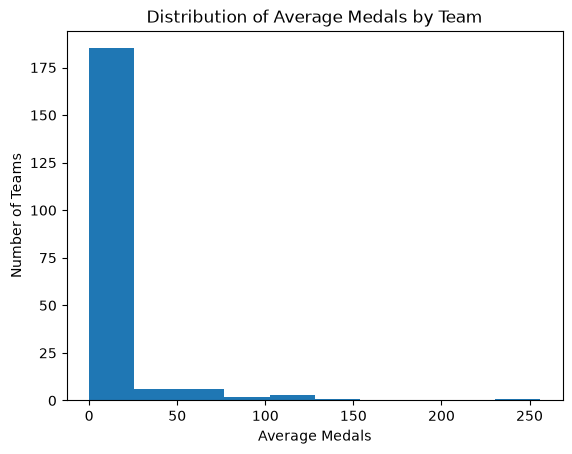

In [79]:
import matplotlib.pyplot as plt

plt.hist(medals_by_team)
plt.xlabel("Average Medals")
plt.ylabel("Number of Teams")
plt.title("Distribution of Average Medals by Team")
plt.show()

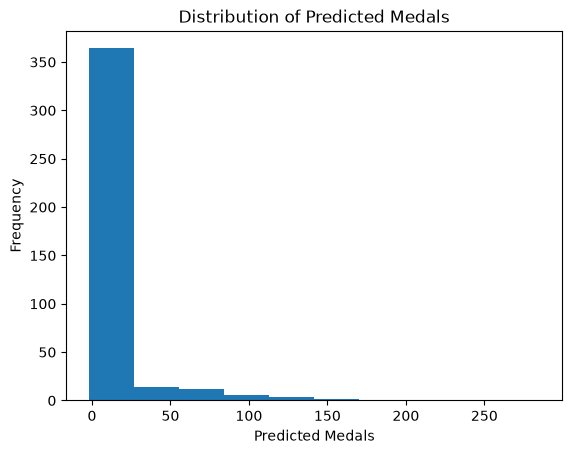

In [80]:
predictions_clean = predictions[np.isfinite(predictions)]

plt.hist(predictions_clean)
plt.xlabel("Predicted Medals")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Medals")
plt.show()